### Reading data and creating features

In [79]:
import pandas as pd
import numpy as np

df = pd.read_excel("C:/Users/Shraddha/Downloads/hotel_daily_booking_data_2024_2025.xlsx",skiprows=1)
df['date'] = pd.to_datetime(df['date'])

In [80]:
print(df.shape)

(2193, 9)


In [81]:
df = df.sort_values(['room_type','date'])

In [82]:
df['month'] = df['date'].dt.month
#df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week.astype(int)

In [83]:
df = df.sort_values(['room_type', 'date'])

df['lag_1'] = df.groupby('room_type')['bookings'].shift(1)


df['lag_7'] = df.groupby('room_type')['bookings'].shift(7)


df['rolling_7'] =  df.groupby('room_type')['bookings'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df['price_lag_1']      = df.groupby('room_type')['price_inr'].shift(1)
df['price_lag_7']      = df.groupby('room_type')['price_inr'].shift(7)
df['price_rolling_7']  = df.groupby('room_type')['price_inr'].transform(lambda x: x.shift(1).rolling(7).mean())


df = df.dropna(subset=['lag_1', 'lag_7', 'rolling_7', 'price_lag_1', 'price_lag_7', 'price_rolling_7'])



In [84]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in ['room_type','day_of_week']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df = pd.get_dummies(df,columns=['event_name'],drop_first=True)

In [85]:
print(encoders['day_of_week'].classes_)
print(encoders['room_type'].classes_)

['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']
['Deluxe' 'Standard' 'Suite']


In [86]:
#future['room_type'] = encoders['room_type'].inverse_transform(future['room_type'])
#encoders['room_type'].inverse_transform(future['room_type'])


In [87]:
print(df.columns)

Index(['date', 'room_type', 'bookings', 'price_inr', 'occupancy_pct',
       'event_flag', 'day_of_week', 'is_weekend', 'month', 'week', 'lag_1',
       'lag_7', 'rolling_7', 'price_lag_1', 'price_lag_7', 'price_rolling_7',
       'event_name_Diwali', 'event_name_New Year', 'event_name_Tamil New Year',
       'event_name_Valentine's Day'],
      dtype='object')


#### Creating training and validation data . Validation is the last 30 days data

In [89]:
df = df.sort_values(['room_type', 'date'])

In [90]:
cutoff_date = (df['date'].max() - pd.Timedelta(days=30))
train_df = df[df['date'] <= cutoff_date]
val_df = df[df['date'] > cutoff_date]

print(cutoff_date)
print(train_df['date'].min(), train_df['date'].max())
print(val_df['date'].min(), val_df['date'].max())

2025-12-01 00:00:00
2024-01-08 00:00:00 2025-12-01 00:00:00
2025-12-02 00:00:00 2025-12-31 00:00:00


#### XGboost fine tuning with NO PRICE features 

In [92]:
y = df['bookings']
features = ['room_type', 'day_of_week','is_weekend','month',
            'week', 'lag_1','lag_7','rolling_7', 'event_name_Diwali',
            'event_name_New Year','event_name_Tamil New Year',
            "event_name_Valentine's Day"]

In [93]:
X_train = train_df[features]
y_train = train_df['bookings']

X_val = val_df[features]
y_val = val_df['bookings']

In [94]:
X_train.head()

,room_type,day_of_week,is_weekend,month,week,lag_1,lag_7,rolling_7,event_name_Diwali,event_name_New Year,event_name_Tamil New Year,event_name_Valentine's Day
21,0,1,0,1,2,46.0,57.0,48.428571,False,False,False,False
24,0,5,0,1,2,34.0,51.0,45.142857,False,False,False,False
27,0,6,0,1,2,35.0,41.0,42.857143,False,False,False,False
30,0,4,0,1,2,32.0,39.0,41.571429,False,False,False,False
33,0,0,1,1,2,33.0,47.0,40.714286,False,False,False,False


In [95]:
def evaluate(name, model, X, y):
    preds = model.predict(X)
    mae  = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    mape = np.mean(np.abs((y - preds) / y.clip(lower=1))) * 100
    print(f"{name:10s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%")
    return preds


In [96]:
import optuna
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'early_stopping_rounds': 50,   # ← moved here
        'eval_metric': 'mae',          # ← moved here too
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return mean_absolute_error(y_val, model.predict(X_val))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)

[I 2026-06-12 22:20:24,204] A new study created in memory with name: no-name-e5c9c33e-dcc9-4f35-a612-a4ba84e40503
[I 2026-06-12 22:20:24,553] Trial 0 finished with value: 3.24076500998603 and parameters: {'n_estimators': 217, 'max_depth': 6, 'learning_rate': 0.019063416702092995, 'subsample': 0.6104926529964563, 'colsample_bytree': 0.6975483161715575}. Best is trial 0 with value: 3.24076500998603.
[I 2026-06-12 22:20:25,006] Trial 1 finished with value: 3.091167916191949 and parameters: {'n_estimators': 371, 'max_depth': 6, 'learning_rate': 0.08044901741585432, 'subsample': 0.6977400976480896, 'colsample_bytree': 0.6332962639934276}. Best is trial 1 with value: 3.091167916191949.
[I 2026-06-12 22:20:25,899] Trial 2 finished with value: 2.9773406240675184 and parameters: {'n_estimators': 727, 'max_depth': 4, 'learning_rate': 0.027875086485013946, 'subsample': 0.8700810565540114, 'colsample_bytree': 0.812311563107834}. Best is trial 2 with value: 2.9773406240675184.
[I 2026-06-12 22:20:2

Best params: {'n_estimators': 967, 'max_depth': 3, 'learning_rate': 0.06393828468172742, 'subsample': 0.7866211146967161, 'colsample_bytree': 0.715552964400834}


In [97]:
#Best params: {'n_estimators': 624, 'max_depth': 3, 'learning_rate': 0.09033795549128364, 
#'subsample': 0.7555651059443409, 'colsample_bytree': 0.8253954417760043}

In [98]:
best_xgb = XGBRegressor(
    **study.best_params,
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42
)
best_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_best_pred = evaluate("XGBoost (Tuned) Test", best_xgb, X_val, y_val)
xgb_best_trainpred = evaluate("XGBoost (Tuned) Train", best_xgb, X_train, y_train)

XGBoost (Tuned) Test | MAE: 2.78 | RMSE: 3.98 | MAPE: 7.7%
XGBoost (Tuned) Train | MAE: 1.58 | RMSE: 2.22 | MAPE: 5.9%


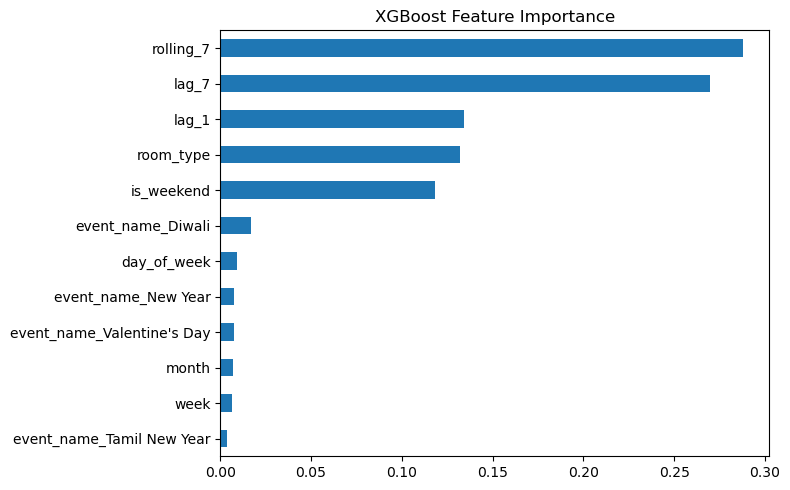

In [99]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(best_xgb.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [100]:
#print(xgb_best_pred,y_val)

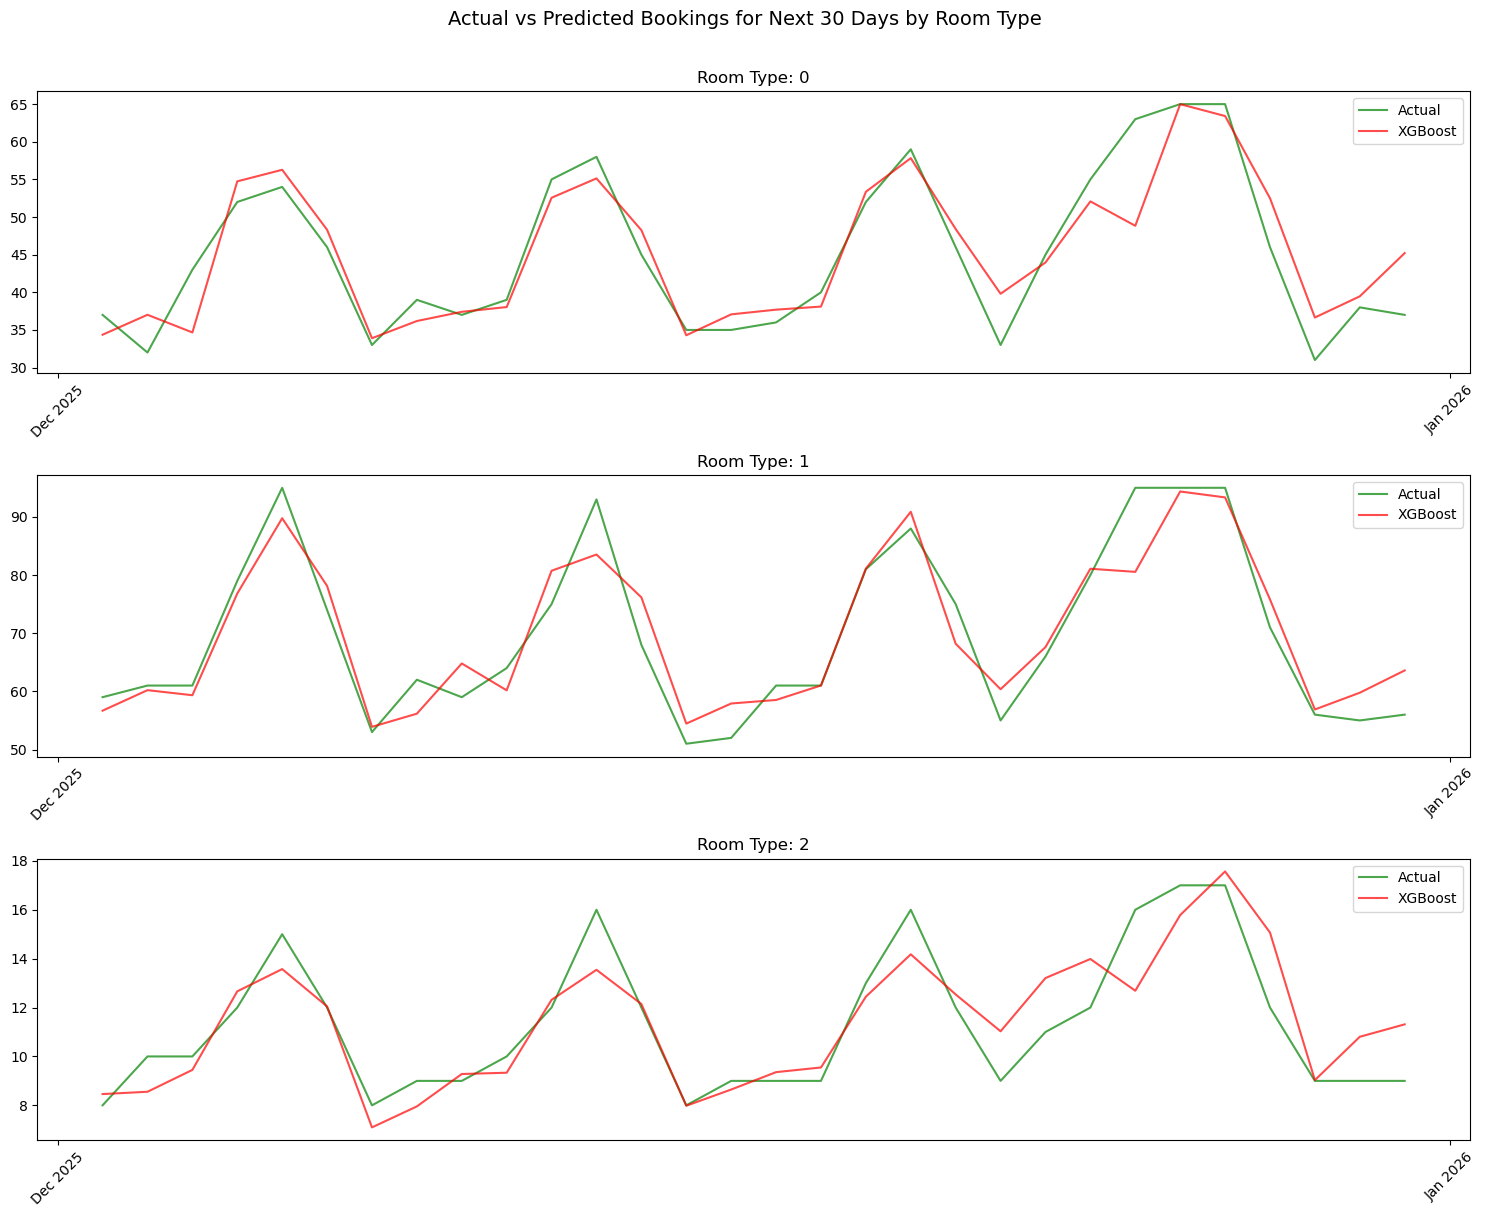

In [101]:
import matplotlib.dates as mdates
fig, axes = plt.subplots(len(val_df['room_type'].unique()), 1, 
                          figsize=(15, 4 * len(val_df['room_type'].unique())))

for ax, room in zip(axes, val_df['room_type'].unique()):
    mask = val_df['room_type'] == room
    
    ax.plot(val_df.loc[mask, 'date'], y_val[mask].values, 
            label='Actual', color='green', alpha=0.7)
    ax.plot(val_df.loc[mask, 'date'], xgb_best_pred[mask], 
            label='XGBoost', color='red', alpha=0.7)
    
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"Room Type: {room}")
    ax.legend()

plt.suptitle("Actual vs Predicted Bookings for Next 30 Days by Room Type", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Added price features with lag and rolling metric

In [103]:
y = df['bookings']
features_price = [
    'room_type', 'day_of_week', 'is_weekend', 'month', 'week',
    'lag_1', 'lag_7', 'rolling_7',
    'price_lag_1', 'price_lag_7', 'price_rolling_7',   # ← new
    'event_name_Diwali', 'event_name_New Year',
    'event_name_Tamil New Year', "event_name_Valentine's Day"
]


In [104]:
X_train = train_df[features_price]
y_train = train_df['bookings']

X_val = val_df[features_price]
y_val = val_df['bookings']

#### Xgboost fine tuning with PRICE features

In [106]:
# ── 1. Tune XGBoost ─────────────────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 0.5),
        'early_stopping_rounds': 50,
        'eval_metric': 'mae',
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return mean_absolute_error(y_val, model.predict(X_val))

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=50)
print("Best XGBoost MAE:", xgb_study.best_value)
print("Best XGBoost params:", xgb_study.best_params)

# ── 3. Train final models with best params ──────────────────────────────────
final_xgb_price = XGBRegressor(
    **xgb_study.best_params,
    early_stopping_rounds=50,
    eval_metric='mae',
    random_state=42
)
final_xgb_price.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

[I 2026-06-12 22:20:49,227] A new study created in memory with name: no-name-f5bce5fb-2915-4a3c-ac27-7d18c950e9d0
[I 2026-06-12 22:20:49,580] Trial 0 finished with value: 3.168255827162001 and parameters: {'n_estimators': 376, 'max_depth': 3, 'learning_rate': 0.023496133942701357, 'subsample': 0.7233265564644962, 'colsample_bytree': 0.8212384895377871, 'min_child_weight': 5, 'gamma': 0.021584127091446192}. Best is trial 0 with value: 3.168255827162001.
[I 2026-06-12 22:20:50,017] Trial 1 finished with value: 3.7028237448798285 and parameters: {'n_estimators': 242, 'max_depth': 6, 'learning_rate': 0.010761767861688584, 'subsample': 0.9179170501185403, 'colsample_bytree': 0.9875713678855157, 'min_child_weight': 5, 'gamma': 0.24551520293359752}. Best is trial 0 with value: 3.168255827162001.
[I 2026-06-12 22:20:50,399] Trial 2 finished with value: 3.0162996927897137 and parameters: {'n_estimators': 270, 'max_depth': 5, 'learning_rate': 0.025041308261156886, 'subsample': 0.7824624951488859

Best XGBoost MAE: 2.576093218061659
Best XGBoost params: {'n_estimators': 484, 'max_depth': 6, 'learning_rate': 0.0691732736093482, 'subsample': 0.738227062728727, 'colsample_bytree': 0.6363605136475887, 'min_child_weight': 3, 'gamma': 0.2567610898997857}


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6363605136475887, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='mae', feature_types=None, feature_weights=None,
             gamma=0.2567610898997857, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.0691732736093482,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=484, n_jobs=None,
             num_parallel_tree=None, ...)

In [107]:
xgbprice_best_pred = evaluate("XGBoost (Tuned) Test", final_xgb_price, X_val, y_val)
xgbprice_best_trainpred = evaluate("XGBoost (Tuned) Train", final_xgb_price, X_train, y_train)

XGBoost (Tuned) Test | MAE: 2.58 | RMSE: 3.44 | MAPE: 6.8%
XGBoost (Tuned) Train | MAE: 1.19 | RMSE: 1.67 | MAPE: 4.6%


In [108]:
val_result = val_df[['date','room_type','bookings']].copy()

val_result['prediction_xgb'] = xgb_best_pred
val_result['prediction_xgb_price'] = xgbprice_best_pred

val_result['median_bookings'] = val_result[['prediction_xgb','prediction_xgb_price']].median(axis=1)

In [109]:
val_result.head(10)

,date,room_type,bookings,prediction_xgb,prediction_xgb_price,median_bookings
2103,2025-12-02,0,37,34.365562,35.227623,34.796593
2106,2025-12-03,0,32,37.014969,37.852436,37.433701
2109,2025-12-04,0,43,34.667728,34.835083,34.751404
2112,2025-12-05,0,52,54.741299,54.714912,54.728104
2115,2025-12-06,0,54,56.275841,55.706795,55.991318
2118,2025-12-07,0,46,48.309204,49.510521,48.909863
2121,2025-12-08,0,33,33.901806,33.123978,33.512894
2124,2025-12-09,0,39,36.185081,35.367020,35.776051
2127,2025-12-10,0,37,37.409195,38.487118,37.948158
2130,2025-12-11,0,39,38.042221,38.852493,38.447357


In [110]:
mae  = mean_absolute_error(val_result['bookings'], val_result['median_bookings'])
rmse = np.sqrt(mean_squared_error(val_result['bookings'], val_result['median_bookings']))
mape = np.mean(np.abs((val_result['bookings']-val_result['median_bookings']) / y.clip(lower=1))) * 100
print(f" MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%")

 MAE: 2.62 | RMSE: 3.62 | MAPE: 6.9%


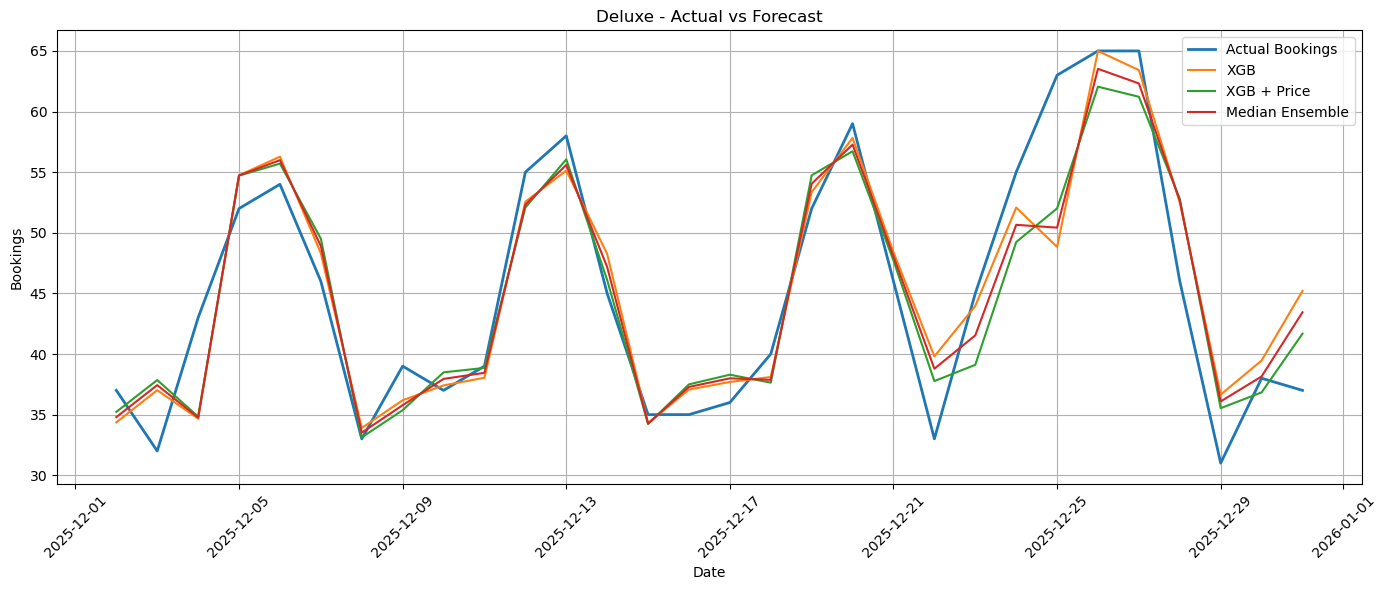

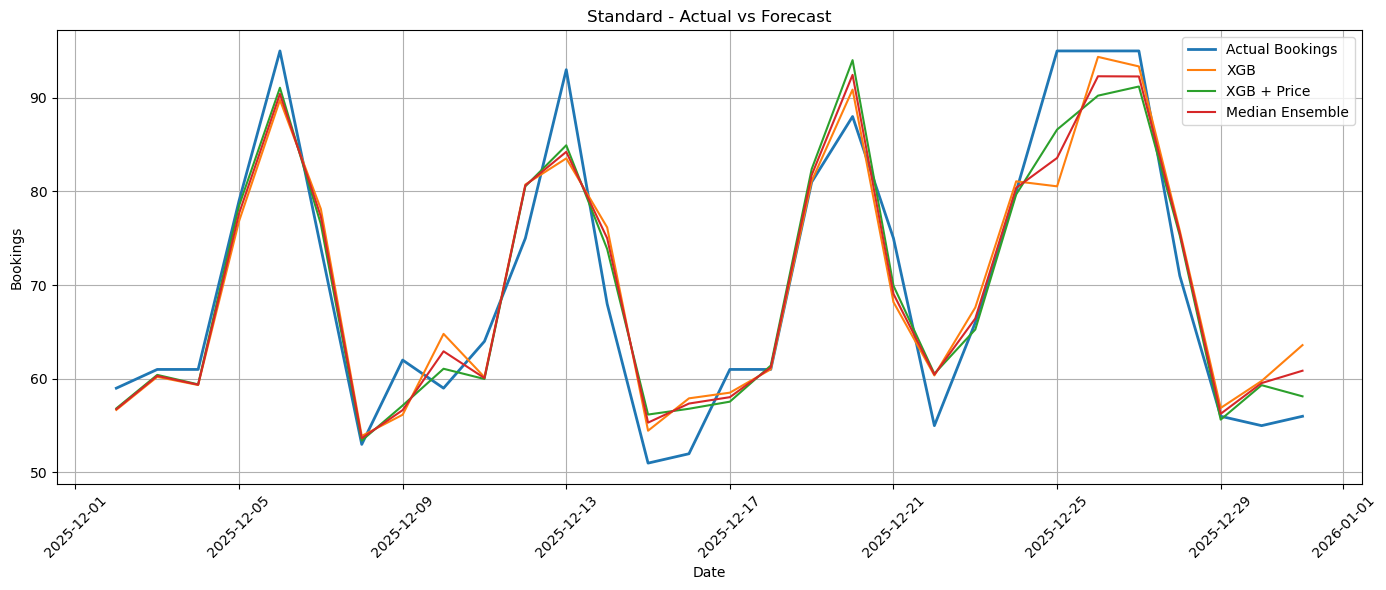

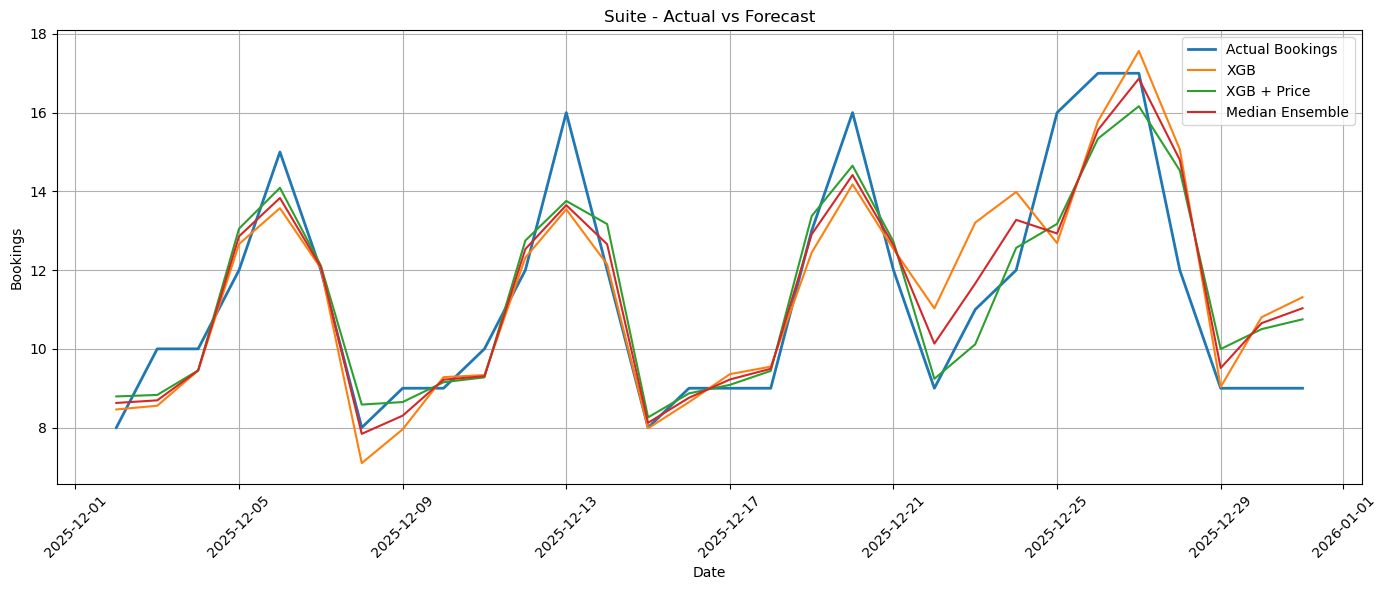

In [111]:
import matplotlib.pyplot as plt

room_map = {
    0: 'Deluxe',
    1: 'Standard',
    2: 'Suite'
}

for room in sorted(val_result['room_type'].unique()):

    temp = (
        val_result[val_result['room_type'] == room]
        .sort_values('date')
    )

    plt.figure(figsize=(14,6))

    plt.plot(
        temp['date'],
        temp['bookings'],
        label='Actual Bookings',
        linewidth=2
    )

    plt.plot(
        temp['date'],
        temp['prediction_xgb'],
        label='XGB'
    )

    plt.plot(
        temp['date'],
        temp['prediction_xgb_price'],
        label='XGB + Price'
    )

    plt.plot(
        temp['date'],
        temp['median_bookings'],
        label='Median Ensemble'
    )

    plt.title(f"{room_map.get(room, room)} - Actual vs Forecast")
    plt.xlabel("Date")
    plt.ylabel("Bookings")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [145]:
val_result['room_type'] = encoders['room_type'].inverse_transform(val_result['room_type'])

In [147]:
val_result.head()

,date,room_type,bookings,prediction_xgb,prediction_xgb_price,median_bookings
2103,2025-12-02,Deluxe,37,34.365562,35.227623,34.796593
2106,2025-12-03,Deluxe,32,37.014969,37.852436,37.433701
2109,2025-12-04,Deluxe,43,34.667728,34.835083,34.751404
2112,2025-12-05,Deluxe,52,54.741299,54.714912,54.728104
2115,2025-12-06,Deluxe,54,56.275841,55.706795,55.991318


In [149]:
#val_result.to_csv("C:/Users/Shraddha/Downloads/hotel_booking_models/hotel_booking/hotel_booking_forecast.csv")